## Session 18 - Optional Task (Insurance Dataset)

### Insurance Dataset - Complete Data Analysis and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("insurance.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

First 10 Rows:
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14

Last 5 Rows:
      age     sex   bmi  children smoker     region  expenses
1333   50    male  31.0         3     no  northwest  10600.55
1334   18  female  31.9         0     no  northeast   2205.98
1335   18  female  36.9         0     no  southeast   1629.83
1336   21  female  25.8         0     no  southwest   2007.95
1337   61  f

In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicate Rows After Removal:")
print(df.duplicated().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Duplicate Rows: 1

Duplicate Rows After Removal:
0


In [4]:
# Display statistical summary
print("Statistical Summary:")
print(df.describe())

# Statistics for important numeric columns
columns = ["age", "bmi", "children", "expenses"]

for col in columns:
    print(f"\n{col.upper()} Statistics")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("Mean    :", df[col].mean())
    print("Median  :", df[col].median())

Statistical Summary:
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000

AGE Statistics
Minimum : 18
Maximum : 64
Mean    : 39.222139117427076
Median  : 39.0

BMI Statistics
Minimum : 16.0
Maximum : 53.1
Mean    : 30.665519820493646
Median  : 30.4

CHILDREN Statistics
Minimum : 0
Maximum : 5
Mean    : 1.0957367240089753
Median  : 1.0

EXPENSES Statistics
Minimum : 1121.87
Maximum : 63770.43
Mean    : 13279.121637995511
Median  : 9386.16


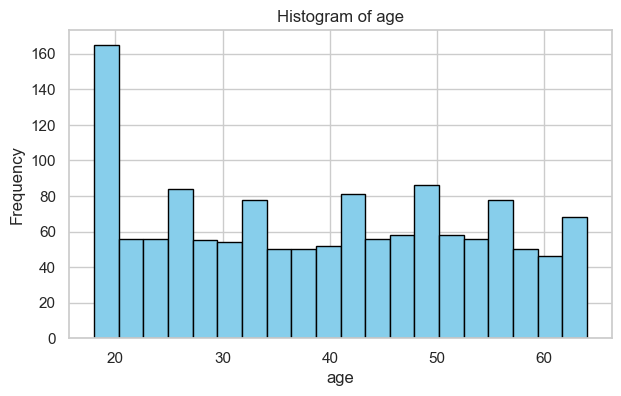

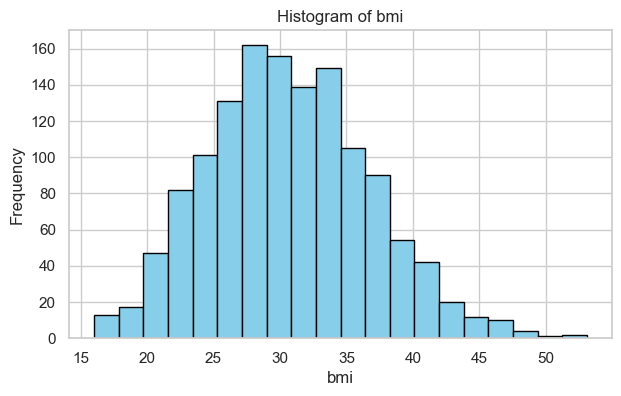

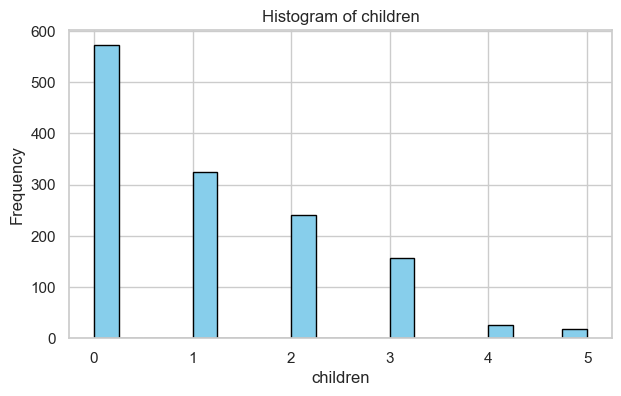

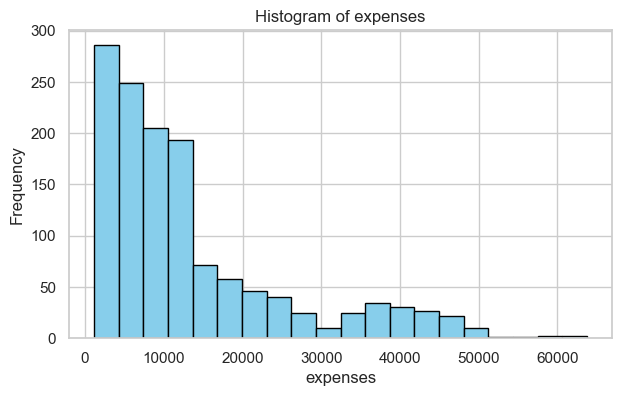

In [5]:
# List of numeric columns
numeric_columns = ["age", "bmi", "children", "expenses"]

# Plot histograms
for col in numeric_columns:
    plt.figure(figsize=(7, 4))

    plt.hist(df[col], bins=20, edgecolor="black", color="skyblue")

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

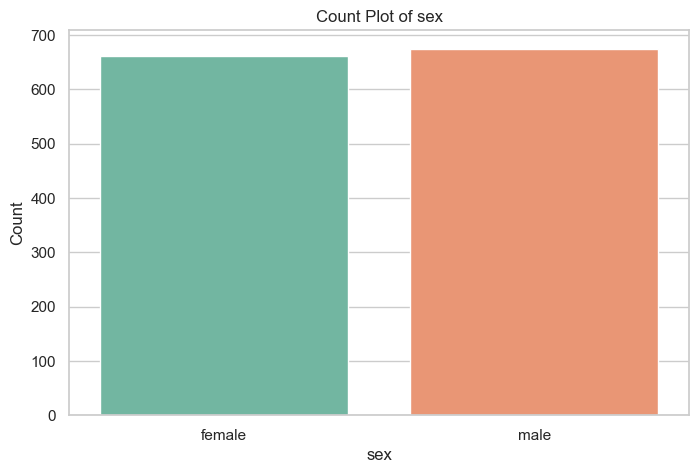

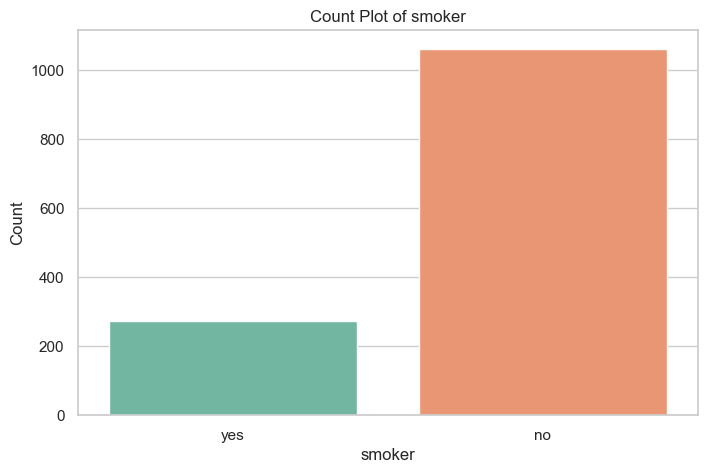

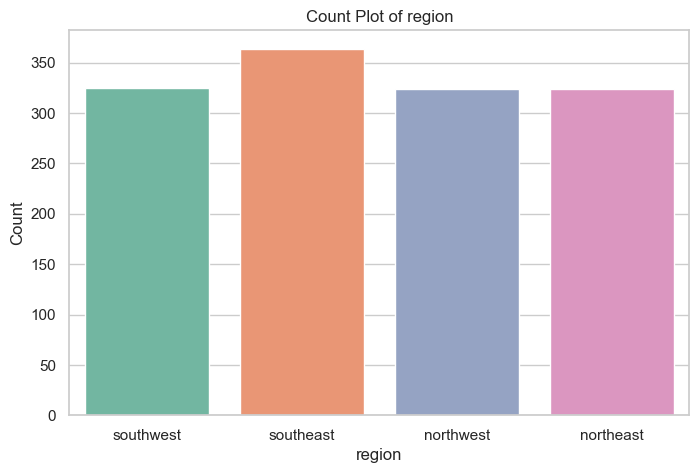

In [6]:
# List of categorical columns
categorical_columns = ["sex", "smoker", "region"]

# Plot count plots
for col in categorical_columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="Set2",
        legend=False
    )

    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

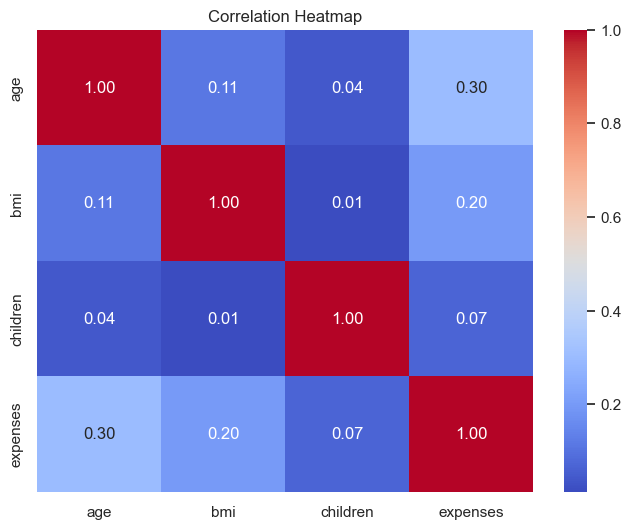

Correlation with Expenses:
expenses    1.000000
age         0.298308
bmi         0.198637
children    0.067389
Name: expenses, dtype: float64


In [7]:
# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Display correlation with expenses
print("Correlation with Expenses:")
print(corr_matrix["expenses"].sort_values(ascending=False))

In [8]:
# Independent Features
X = df.drop("expenses", axis=1)

# Dependent Feature
y = df["expenses"]

print("Independent Features:")
print(X.columns.tolist())

print("\nDependent Feature:")
print(y.name)

Independent Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Dependent Feature:
expenses


In [9]:
# Display original categorical columns
print("Before One Hot Encoding:")
print(df[["sex", "smoker"]].head())

# Apply One Hot Encoding
encoded_df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

# Display encoded columns
print("\nAfter One Hot Encoding:")
print(encoded_df.head())

print("\nShape Before Encoding:", df.shape)
print("Shape After Encoding:", encoded_df.shape)

Before One Hot Encoding:
      sex smoker
0  female    yes
1    male     no
2    male     no
3    male     no
4    male     no

After One Hot Encoding:
   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Shape Before Encoding: (1337, 7)
Shape After Encoding: (1337, 9)


In [10]:
from sklearn.preprocessing import StandardScaler

# Select numeric independent features
numeric_features = ["age", "bmi", "children"]

# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling
scaled_data = scaler.fit_transform(df[numeric_features])

# Convert to DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_features
)

# Display first 5 rows
print("First 5 Rows of Scaled Data:")
print(scaled_df.head())

First 5 Rows of Scaled Data:
        age       bmi  children
0 -1.440418 -0.453484 -0.909234
1 -1.511647  0.513986 -0.079442
2 -0.799350  0.382803  1.580143
3 -0.443201 -1.306169 -0.909234
4 -0.514431 -0.289506 -0.909234


In [11]:
from sklearn.preprocessing import StandardScaler

# Remove duplicate rows
df = df.drop_duplicates()

# Define input and output features
X = df.drop("expenses", axis=1)
y = df["expenses"]

# Apply One Hot Encoding
X = pd.get_dummies(
    X,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

# Select numeric columns for scaling
numeric_features = ["age", "bmi", "children"]

# Apply Standard Scaling
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Display preprocessed data
print("Preprocessed Dataset:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Preprocessed Dataset:
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453484 -0.909234     False        True             False   
1 -1.511647  0.513986 -0.079442      True       False             False   
2 -0.799350  0.382803  1.580143      True       False             False   
3 -0.443201 -1.306169 -0.909234      True       False              True   
4 -0.514431 -0.289506 -0.909234      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Target Variable:
0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64


### Summary

• **Data Exploration**

* Loaded and explored the dataset.
* Checked the shape, columns, and data types.

• **Data Cleaning**

* Identified missing values and duplicate records.
* Cleaned the dataset for analysis.

• **Data Analysis**

* Generated summary statistics.
* Created histograms, count plots, and a correlation heatmap.

• **Preprocessing**

* Identified input and target features.
* Applied One Hot Encoding and Standard Scaling.

• **Key Learning**

* Learned the complete data preprocessing workflow.
* Prepared the dataset for a regression machine learning model.
